# Прототип книжного рекомендательного сервиса (goodbooks-10k)

Лабораторный журнал решения: вызовы функций пакета `recsys` (`src/recsys`), промежуточные таблицы и графики. Постановка, обоснования и итоговые выводы — в `README.md`. Графики, используемые в README, сохраняются в `reports/figures/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from recsys import data, eda, plots

pd.set_option("display.float_format", "{:.4f}".format)
plots.set_style()

dataset = data.load_all()
ratings = dataset.ratings
pd.Series(data.validate(dataset), name="value").to_frame()

,value
n_ratings,5976479
n_users,53424
n_books,10000
n_tags,34252
n_book_tags,999912
book_tags_duplicate_pairs,8
book_tags_nonpositive_count,6
books_missing_original_title,585


## 1. Разведочный анализ данных (EDA)

### 1.1. Общая статистика

In [2]:
eda.summary(ratings).to_frame("value")

,value
n_ratings,5976479.0000
n_users,53424.0000
n_books,10000.0000
density,0.0112
sparsity,0.9888
rating_mean,3.9199
rating_median,4.0000
share_relevant,0.6897


Заполненность матрицы 1.12 %; дубликатов пар `(user_id, book_id)` и пропусков нет.

### 1.2. Распределение оценок

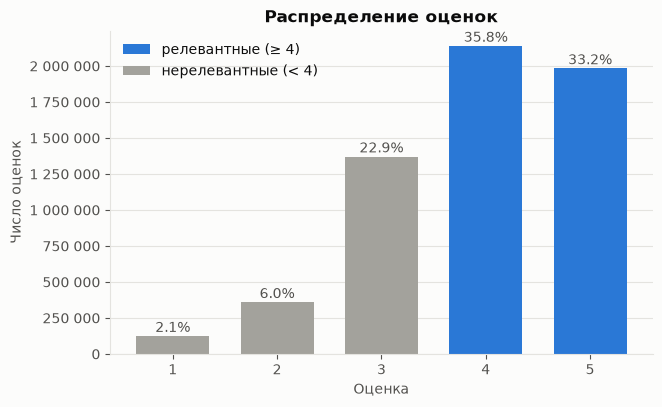

,count,share
rating,,
1,124195,0.0208
2,359257,0.0601
3,1370916,0.2294
4,2139018,0.3579
5,1983093,0.3318


In [3]:
distribution = eda.rating_distribution(ratings)
fig = plots.plot_rating_distribution(distribution)
plots.save_figure(fig, "rating_distribution")
plt.show()
distribution

Оценки 4–5 составляют 69.0 %, 1–2 — 8.1 %; при пороге 3 релевантными были бы 92 % оценок.

### 1.3. Активность пользователей

In [4]:
user_counts = eda.user_counts(ratings)
book_counts = eda.book_counts(ratings)
pd.DataFrame({"users": eda.describe_counts(user_counts), "books": eda.describe_counts(book_counts)})

,users,books
min,19.0000,8.0000
q01,40.0000,72.9900
q10,82.0000,115.0000
q25,96.0000,155.0000
median,111.0000,248.0000
q75,128.0000,503.0000
q90,146.0000,1180.3000
q99,176.0000,6305.0200
max,200.0000,22806.0000
mean,111.8688,597.6479


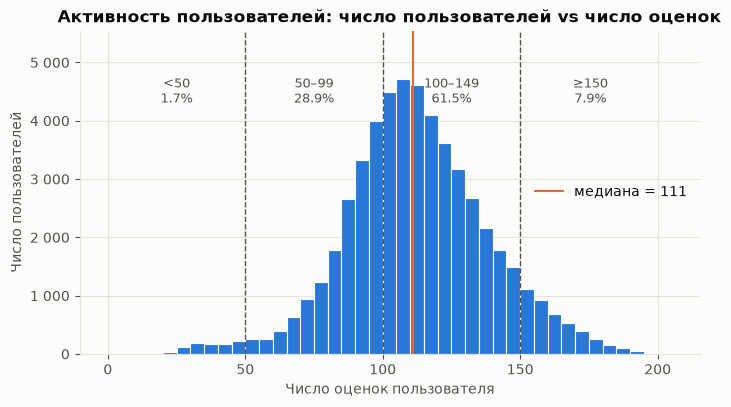

,n_users,share_users,share_ratings,mean_rating
segment,,,,
<50,899,0.0168,0.0056,3.8526
50–99,15441,0.2890,0.2221,3.9879
100–149,32849,0.6149,0.6571,3.9129
≥150,4235,0.0793,0.1152,3.8492


In [5]:
fig = plots.plot_user_activity(user_counts)
plots.save_figure(fig, "user_activity")
plt.show()
eda.user_segments(ratings)

Диапазон 19–200 оценок на пользователя, медиана 111; сегмент `<50` — 899 пользователей (1.7 %), его средняя оценка (3.85) ниже, чем у сегмента `50–99` (3.99).

### 1.4. Популярность книг и long tail

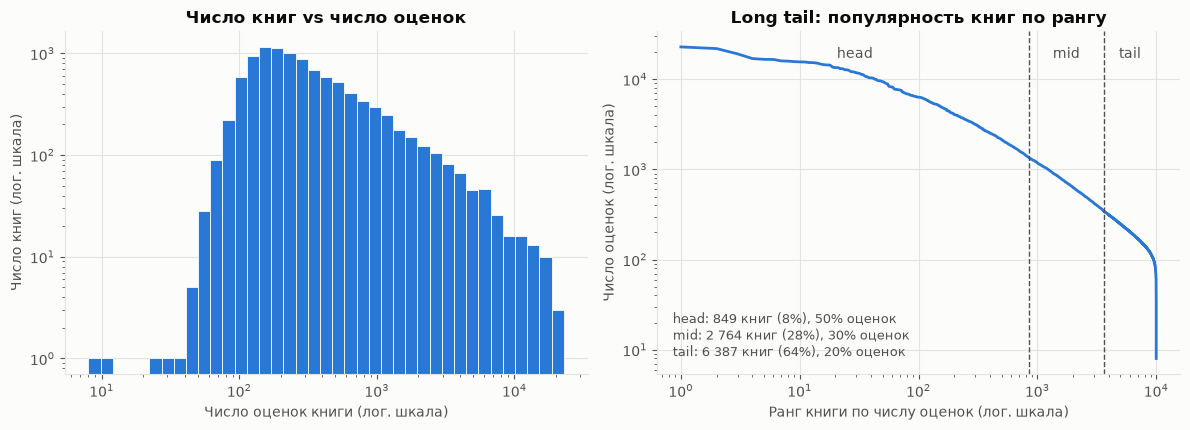

,n_books,share_books,share_ratings,min_ratings,max_ratings
segment,,,,,
head,849,0.0849,0.5001,1348,22806
mid,2764,0.2764,0.2999,346,1347
tail,6387,0.6387,0.2000,8,346


In [6]:
fig = plots.plot_book_popularity(book_counts)
plots.save_figure(fig, "book_popularity")
plt.show()
eda.popularity_table(book_counts)

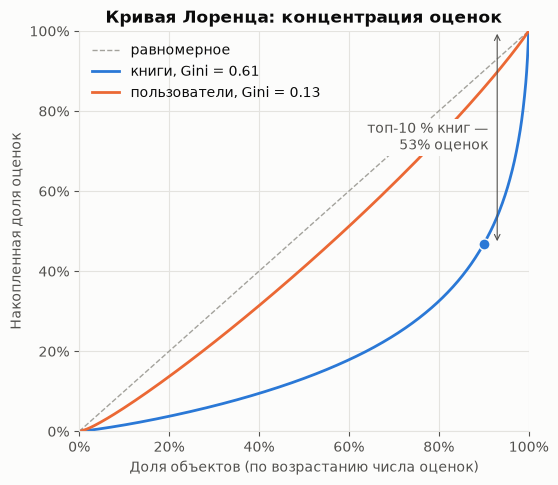

,value
top_1%,0.1709
top_10%,0.5320
top_20%,0.6750
gini_books,0.6127
gini_users,0.1293


In [7]:
fig = plots.plot_lorenz(book_counts, user_counts)
plt.show()
pd.concat(
    [
        eda.top_share(book_counts),
        pd.Series({"gini_books": eda.gini(book_counts), "gini_users": eda.gini(user_counts)}),
    ]
).to_frame("value")

Head — 849 книг (8.5 %) с 50 % оценок, long tail — 6 387 книг (63.9 %) с 20 % оценок; на топ-10 % книг приходится 53.2 % оценок.

### 1.5. Теги книг

In [8]:
usage = data.tag_usage(dataset)
raw_frequency = eda.tag_frequency(usage)
service_mask = pd.Series(
    data.is_service_tag(raw_frequency.index.to_series()).to_numpy(), index=raw_frequency.index
)
book_tags = data.clean_book_tags(dataset)
clean_frequency = eda.tag_frequency(book_tags)

service_rows = data.is_service_tag(usage["tag_name"])
pd.Series(
    {
        "raw_tags": raw_frequency.shape[0],
        "service_tags": int(service_mask.sum()),
        "service_share_rows": service_rows.mean(),
        "service_share_count": usage.loc[service_rows, "count"].sum() / usage["count"].sum(),
        "clean_tags": clean_frequency.shape[0],
        "clean_tags_per_book_median": book_tags.groupby("book_id").size().median(),
    }
).to_frame("value")

,value
raw_tags,34250.0000
service_tags,5394.0000
service_share_rows,0.4435
service_share_count,0.7996
clean_tags,28830.0000
clean_tags_per_book_median,53.0000


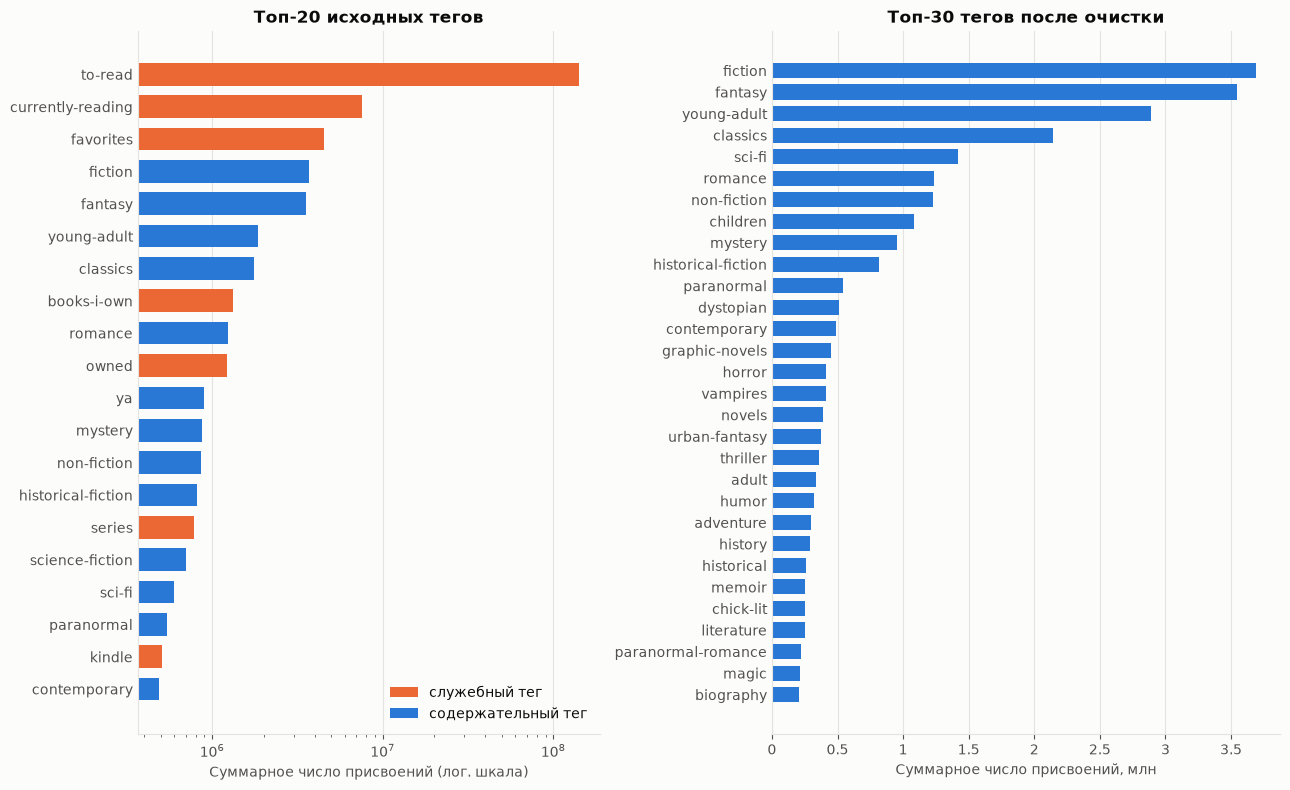

,n_books,total_count
tag_name,,
fiction,9097,3688819
fantasy,4259,3548157
young-adult,3701,2887190
classics,2854,2141495
sci-fi,2476,1420757
romance,4251,1231926
non-fiction,2153,1228950
children,1494,1081274
mystery,3693,951120


In [9]:
fig = plots.plot_top_tags(raw_frequency, service_mask, clean_frequency)
plots.save_figure(fig, "top_tags")
plt.show()
clean_frequency.head(30)

Служебные теги: 5 394 тега, 44 % записей и 80 % присвоений. После очистки — 28 830 тегов, медиана 53 тега на книгу.

### 1.6. Дополнительный анализ

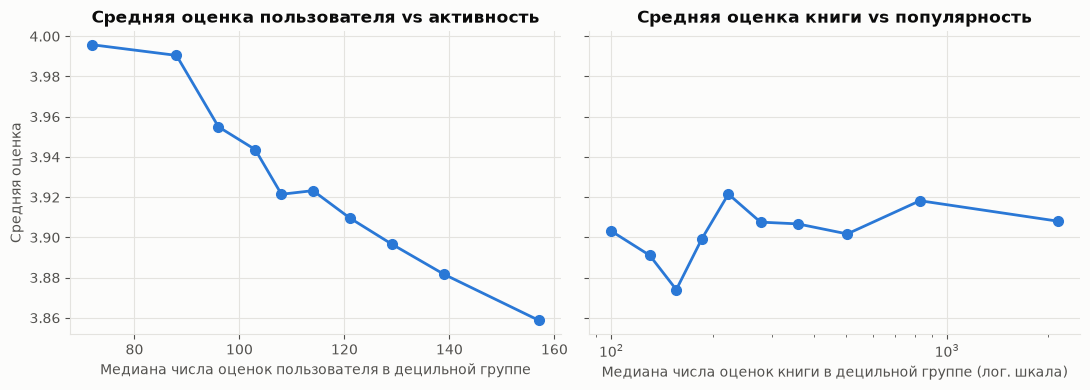

,value
sorted_by_user,False
blocks_per_user,53.6456
median_span_share,0.3153


In [10]:
users_by_activity = eda.activity_vs_rating(ratings, "user_id")
books_by_popularity = eda.activity_vs_rating(ratings, "book_id")
fig = plots.plot_activity_vs_rating(users_by_activity, books_by_popularity)
plt.show()
eda.chronology_check(ratings).to_frame("value")

Средняя оценка пользователя снижается с ростом активности (4.00 → 3.86 по децилям), средняя оценка книги от популярности практически не зависит (3.87–3.92). Оценки пользователя распределены по всему файлу (53.6 блока на пользователя, медианный размах 31.5 % длины файла) — порядок строк глобальный по времени.

## 2. Протокол оценки, Popularity, Content-Based

### 2.1. Разбиение и набор оценки

In [11]:
from recsys import config, evaluation, split
from recsys.models import ContentBased, Popularity

outer = split.temporal_split(ratings)
inner = split.temporal_split(outer.train)
parts = {"train": outer.train, "test": outer.test, "train_inner": inner.train, "valid": inner.test}
pd.DataFrame(
    {
        name: {
            "ratings": len(part),
            "users": part["user_id"].nunique(),
            "books": part["book_id"].nunique(),
            "share_relevant": (part["rating"] >= config.RELEVANCE_THRESHOLD).mean(),
        }
        for name, part in parts.items()
    }
).T

,ratings,users,books,share_relevant
train,4781208.0000,53424.0000,10000.0000,0.6913
test,1195271.0000,53424.0000,10000.0000,0.6832
train_inner,3824978.0000,53424.0000,10000.0000,0.6957
valid,956230.0000,53424.0000,9998.0000,0.6740


In [12]:
assert outer.train.index.intersection(outer.test.index).empty
assert inner.test.index.isin(outer.train.index).all()

valid_set = evaluation.build_eval_set(inner.train, inner.test)
valid_relevant = inner.test[inner.test["rating"] >= config.RELEVANCE_THRESHOLD]
pd.Series(
    {
        "users_with_relevant": valid_relevant["user_id"].nunique(),
        "eval_users": valid_set.user_ids.size,
        "n_relevant_mean": valid_set.n_relevant.mean(),
        "n_relevant_median": float(pd.Series(valid_set.n_relevant).median()),
        "catalog_in_train": valid_set.n_catalog,
    }
).to_frame("value")

,value
users_with_relevant,53160.0000
eval_users,10000.0000
n_relevant_mean,12.1514
n_relevant_median,12.0000
catalog_in_train,10000.0000


Каждый пользователь получает 20 % последних оценок в test (1 195 271 оценка), из оставшихся 80 % — ещё 20 % в valid. Подбор гиперпараметров — на valid по выборке 10 000 пользователей, test не используется.

### 2.2. Popularity

In [13]:
grid_models = [Popularity("count")]
grid_models += [
    Popularity("mean", m) for m in (1, 10, 100, 500, 1000, 2000, 5000, 7000, 8000, 10000)
]
grid_models += [Popularity("weighted", m) for m in (10, 100, 1000, 10000, 100000, 1000000)]
columns = ["precision", "recall", "ndcg", "hit_rate", "coverage", "novelty", "short_lists"]
rows = []
for model in grid_models:
    result = evaluation.evaluate(model.fit(inner.train), valid_set, ks=(10,)).iloc[0]
    rows.append(
        {
            "method": model.method,
            "min_ratings": model.min_ratings,
            "n_candidates": model.n_candidates,
            **result[columns],
        }
    )
popularity_grid = pd.DataFrame(rows)
popularity_grid

,method,min_ratings,n_candidates,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
0,count,0,10000,0.0348,0.0291,0.0383,0.2076,0.0047,8.1939,0.0000
1,mean,1,10000,0.0006,0.0005,0.0005,0.0053,0.0015,17.6030,0.0000
2,mean,10,9925,0.0008,0.0007,0.0009,0.0063,0.0017,15.5694,0.0000
3,mean,100,6742,0.0016,0.0014,0.0017,0.0136,0.0020,14.1711,0.0000
4,mean,500,1520,0.0081,0.0065,0.0071,0.0694,0.0017,11.6505,0.0000
5,mean,1000,720,0.0114,0.0095,0.0110,0.1009,0.0022,10.9394,0.0000
6,mean,2000,307,0.0280,0.0233,0.0265,0.1624,0.0028,9.2705,0.0000
7,mean,5000,81,0.0353,0.0295,0.0391,0.2031,0.0040,8.5952,0.0000
8,mean,7000,49,0.0386,0.0323,0.0417,0.2134,0.0040,8.4578,0.0000
9,mean,8000,37,0.0387,0.0324,0.0425,0.2015,0.0037,8.3197,0.0022


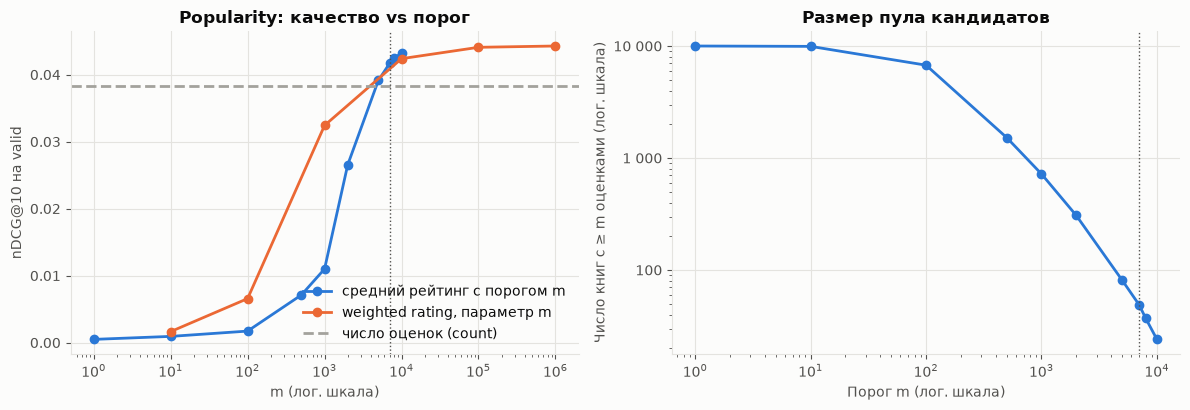

In [14]:
count_ndcg = popularity_grid.loc[popularity_grid["method"] == "count", "ndcg"].item()
fig = plots.plot_popularity_threshold(popularity_grid, count_ndcg, config.POPULARITY_MIN_RATINGS)
plt.show()

Без порога top-10 по среднему рейтингу состоит из книг с единичными оценками 5 (nDCG@10 < 0.001). С ростом порога nDCG@10 растёт; порог выбирается как максимум nDCG@10 при полных списках top-10 (`short_lists` = 0): m = 7 000, пул — 49 книг. При m ≥ 8 000 пула не хватает для части пользователей. Weighted rating выходит на плато 0.044 при m ≥ 10⁵, т.е. при m ≫ v ранжирование по Σ(r − C).

In [15]:
popularity_mean = Popularity("mean", config.POPULARITY_MIN_RATINGS).fit(inner.train)
popularity_mean.top_n(dataset.books, 10)

,book_id,title,authors,n_ratings,mean_rating,score
0,25,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré",11301,4.5305,4.5305
1,27,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré",11117,4.4444,4.4444
2,24,Harry Potter and the Goblet of Fire (Harry Pot...,"J.K. Rowling, Mary GrandPré",11536,4.4343,4.4343
3,18,Harry Potter and the Prisoner of Azkaban (Harr...,"J.K. Rowling, Mary GrandPré, Rufus Beck",11885,4.4172,4.4172
4,31,The Help,Kathryn Stockett,9669,4.4031,4.4031
5,39,"A Game of Thrones (A Song of Ice and Fire, #1)",George R.R. Martin,7708,4.3732,4.3732
6,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",18807,4.3689,4.3689
7,21,Harry Potter and the Order of the Phoenix (Har...,"J.K. Rowling, Mary GrandPré",11327,4.3646,4.3646
8,4,To Kill a Mockingbird,Harper Lee,15772,4.3392,4.3392
9,47,The Book Thief,Markus Zusak,7017,4.3256,4.3256


### 2.3. Content-Based

In [16]:
content = ContentBased(dataset.books, book_tags)
pd.Series(
    {
        "vocabulary": len(content.vectorizer.vocabulary_),
        "nnz": content.item_vectors.nnz,
        "density": content.item_vectors.nnz
        / (content.item_vectors.shape[0] * content.item_vectors.shape[1]),
        "profile_example": content.profiles.loc[2][:300],
    }
).to_frame("value")

,value
vocabulary,16836
nnz,526662
density,0.0031
profile_example,Harry Potter and the Philosopher's Stone fanta...


In [17]:
content_grid = pd.concat(
    [
        evaluation.evaluate(
            ContentBased(dataset.books, book_tags, n).fit(inner.train), valid_set, ks=(10,)
        )
        for n in (5, 10, 20, 50, None)
    ]
)
content_grid[columns]

,,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
model,k,,,,,,,
Content-Based[tags=5],10,0.0143,0.0129,0.0160,0.1076,0.2292,13.8946,0.0000
Content-Based[tags=10],10,0.0216,0.0192,0.0233,0.1529,0.3510,13.8900,0.0000
Content-Based[tags=20],10,0.0340,0.0301,0.0377,0.2292,0.4663,13.0144,0.0000
Content-Based[tags=50],10,0.0467,0.0404,0.0530,0.2925,0.4928,12.1800,0.0000
Content-Based[tags=all],10,0.0474,0.0411,0.0536,0.2943,0.4881,12.1374,0.0000


Качество растёт с числом тегов в профиле до ~50 и далее не меняется (nDCG@10 0.016 при 5 тегах, 0.054 при всех); используются все очищенные теги.

In [18]:
queries = [2, 1, 10, 7]
pd.concat(
    {
        dataset.books.loc[book_id - 1, "title"]: content.get_similar_books(book_id, n=5)
        for book_id in queries
    },
    names=["query", "rank"],
)

book_id  \
query                                              rank            
Harry Potter and the Sorcerer's Stone (Harry Po... 0          23   
                                                   1          18   
                                                   2          24   
                                                   3          25   
                                                   4          27   
The Hunger Games (The Hunger Games, #1)            0          17   
                                                   1          20   
                                                   2         507   
                                                   3          12   
                                                   4         327   
Pride and Prejudice                                0         171   
                                                   1         230   
                                                   2         471   
                                                   3         451   
                                                   4          63   
The Hobbit                                         0         189   
                                                   1         611   
                                                   2         155   
                                                   3         161   
                                                   4         466   

                                                                                                     title  \
query                                              rank                                                      
Harry Potter and the Sorcerer's Stone (Harry Po... 0     Harry Potter and the Chamber of Secrets (Harry...   
                                                   1     Harry Potter and the Prisoner of Azkaban (Harr...   
                                                   2     Harry Potter and the Goblet of Fire (Harry Pot...   
                                                   3     Harry Potter and the Deathly Hallows (Harry Po...   
                                                   4     Harry Potter and the Half-Blood Prince (Harry ...   
The Hunger Games (The Hunger Games, #1)            0                  Catching Fire (The Hunger Games, #2)   
                                                   1                     Mockingjay (The Hunger Games, #3)   
                                                   2     The Hunger Games Trilogy Boxset (The Hunger Ga...   
                                                   3                             Divergent (Divergent, #1)   
                                                   4                                   Legend (Legend, #1)   
Pride and Prejudice                                0                                                  Emma   
                                                   1                                            Persuasion   
                                                   2                                        Mansfield Park   
                                                   3                                      Northanger Abbey   
                                                   4                                     Wuthering Heights   
The Hobbit                                         0     The Lord of the Rings (The Lord of the Rings, ...   
                                                   1              The Silmarillion (Middle-Earth Universe)   
                                                   2            The Two Towers (The Lord of the Rings, #2)   
                                                   3     The Return of the King (The Lord of the Rings,...   
                                                   4                             The Hobbit: Graphic Novel   

                                                                                                   authors  \
query                        

Похожие книги — продолжения серии, книги того же автора и жанра (для «The Hunger Games» — «Divergent», «Legend»). Название усиливает близость внутри серии, теги — жанровую близость.

### 2.4. Сравнение на valid

In [19]:
content.fit(inner.train)
popularity_weighted = Popularity("weighted", config.POPULARITY_WR_M).fit(inner.train)
popularity_count = Popularity("count").fit(inner.train)
valid_comparison = evaluation.compare(
    [popularity_mean, popularity_weighted, popularity_count, content], valid_set
)
valid_comparison

precision  recall   ndcg    map  hit_rate  \
model                          k                                               
Popularity[mean, m=7000]       5      0.0416  0.0173 0.0425 0.0293    0.1172   
                               10     0.0386  0.0323 0.0417 0.0208    0.2134   
                               20     0.0326  0.0547 0.0480 0.0190    0.3399   
Popularity[weighted, m=100000] 5      0.0465  0.0197 0.0485 0.0305    0.1455   
                               10     0.0386  0.0323 0.0441 0.0219    0.2038   
                               20     0.0309  0.0518 0.0485 0.0195    0.3220   
Popularity[count]              5      0.0346  0.0147 0.0377 0.0205    0.1398   
                               10     0.0348  0.0291 0.0383 0.0159    0.2076   
                               20     0.0314  0.0523 0.0457 0.0163    0.3017   
Content-Based[tags=all]        5      0.0540  0.0239 0.0564 0.0327    0.1959   
                               10     0.0474  0.0411 0.0536 0.0238    0.2943   
                               20     0.0400  0.0684 0.0612 0.0229    0.4146   

                                   coverage  novelty  mean_popularity  \
model                          k                                        
Popularity[mean, m=7000]       5     0.0029   8.4682       11009.9738   
                               10    0.0040   8.4578       11352.2268   
                               20    0.0049   8.5389       10664.1927   
Popularity[weighted, m=100000] 5     0.0029   8.1780       13665.2763   
                               10    0.0039   8.3973       11839.1849   
                               20    0.0057   8.7730        9581.9668   
Popularity[count]              5     0.0038   8.0212       14958.4906   
                               10    0.0047   8.1939       13296.4809   
                               20    0.0071   8.3541       11916.8372   
Content-Based[tags=all]        5     0.3666  12.0048        2449.9687   
                               10    0.4881  12.1374        2226.5077   
                               20    0.6230  12.3004        1973.2057   

                                   short_lists  seconds  
model                          k                         
Popularity[mean, m=7000]       5        0.0000   1.3697  
                               10       0.0000   1.3697  
                               20       0.0063   1.3697  
Popularity[weighted, m=100000] 5        0.0000   1.3813  
                               10       0.0000   1.3813  
                               20       0.0000   1.3813  
Popularity[count]              5        0.0000   1.3654  
                               10       0.0000   1.3654  
                               20       0.0000   1.3654  
Content-Based[tags=all]        5        0.0000   7.9968  
                               10       0.0000   7.9968  
                               20       0.0000   7.9968

На valid Content-Based превосходит все варианты Popularity по точности (nDCG@10 0.054 против 0.038–0.044) и по Coverage@10 (≈ 49 % каталога против < 1 %).

## 3. Item-based Collaborative Filtering

### 3.1. Матрица схожести

In [20]:
import time
import tracemalloc

import numpy as np

from recsys import metrics
from recsys.models import ItemCF
from recsys.models.item_cf import sparse_nbytes

MB = 2**20
tracemalloc.start()
start = time.perf_counter()
item_cf = ItemCF().fit(inner.train)
item_cf_fit_seconds = time.perf_counter() - start
_, item_cf_fit_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

train_inner_matrix = data.interaction_matrix(inner.train)
n_pairs = config.N_BOOKS**2
pd.Series(
    {
        "fit_seconds": item_cf_fit_seconds,
        "fit_peak_mb": item_cf_fit_peak / MB,
        "ratings_csr_mb": sparse_nbytes(train_inner_matrix) / MB,
        "ratings_dense_float32_mb": config.N_USERS * config.N_BOOKS * 4 / MB,
        "similarity_nnz": item_cf.similarity.nnz,
        "similarity_density": item_cf.similarity.nnz / n_pairs,
        "similarity_csr_mb": sparse_nbytes(item_cf.similarity) / MB,
        "similarity_dense_float32_mb": n_pairs * 4 / MB,
        "neighbors_csr_mb": sparse_nbytes(item_cf.neighbors) / MB,
    }
).to_frame("value")

,value
fit_seconds,12.1999
fit_peak_mb,1152.3734
ratings_csr_mb,29.3861
ratings_dense_float32_mb,2037.9639
similarity_nnz,16809942.0000
similarity_density,0.1681
similarity_csr_mb,128.2878
similarity_dense_float32_mb,381.4697
neighbors_csr_mb,3.8525


In [21]:
co_counts = (train_inner_matrix[:, :1000] != 0).T.astype("float32") @ (train_inner_matrix != 0)
co_counts = co_counts.toarray().ravel()
pd.Series(
    {
        "share_pairs_with_common_users": (co_counts > 0).mean(),
        "median_common_users": float(pd.Series(co_counts[co_counts > 0]).median()),
        "share_pairs_below_5_common_users": ((co_counts > 0) & (co_counts < 5)).mean()
        / (co_counts > 0).mean(),
    },
    name="первые 1 000 книг",
).to_frame()

,первые 1 000 книг
share_pairs_with_common_users,0.7418
median_common_users,5.0000
share_pairs_below_5_common_users,0.4950


Схожесть считается блоками по 1 000 книг за 12 с; плотная матрица «пользователь × книга» (2.0 ГБ в float32) не создаётся. Положительна схожесть у 16.8 % пар книг: CSR — 128 МБ против 381 МБ в плотном виде, top-50 соседей — 3.9 МБ. Даже среди книг с `book_id` ≤ 1 000 (самые популярные) у 49.5 % пар с общими читателями таких читателей меньше 5 — схожести этих пар шумные, отсюда shrinkage.

### 3.2. Подбор параметров на valid

In [22]:
valid_users = inner.test["user_id"].to_numpy()
valid_books = inner.test["book_id"].to_numpy()
valid_ratings = inner.test["rating"].to_numpy()
rows = []
for kind in ("cosine", "adjusted_cosine", "pearson"):
    for shrinkage in (0, 10, 50, 100):
        model = ItemCF(kind, n_neighbors=10, shrinkage=shrinkage).fit(inner.train)
        for k in (10, 20, 50, 100, 200):
            model.set_n_neighbors(k)
            prediction = model.predict(valid_users, valid_books)
            result = evaluation.evaluate(model, valid_set, ks=(10,)).iloc[0]
            rows.append(
                {
                    "similarity": kind,
                    "shrinkage": shrinkage,
                    "k": k,
                    "rmse": metrics.rmse(valid_ratings, prediction),
                    "mae": metrics.mae(valid_ratings, prediction),
                    **result[columns],
                }
            )
item_cf_grid = pd.DataFrame(rows)
item_cf_grid.pivot_table(index=["similarity", "shrinkage"], columns="k", values=["rmse", "ndcg"])

ndcg                               rmse         \
k                            10     20     50     100    200    10     20    
similarity      shrinkage                                                    
adjusted_cosine 0         0.0936 0.0934 0.0943 0.0948 0.0956 0.8725 0.8602   
                10        0.0950 0.0950 0.0958 0.0964 0.0966 0.8775 0.8650   
                50        0.0959 0.0965 0.0968 0.0968 0.0970 0.8847 0.8724   
                100       0.0956 0.0958 0.0958 0.0956 0.0955 0.8885 0.8765   
cosine          0         0.0843 0.0825 0.0809 0.0806 0.0793 0.9076 0.8932   
                10        0.0847 0.0831 0.0809 0.0803 0.0788 0.9127 0.8976   
                50        0.0844 0.0825 0.0801 0.0789 0.0773 0.9183 0.9023   
                100       0.0835 0.0814 0.0793 0.0778 0.0758 0.9209 0.9046   
pearson         0         0.0857 0.0865 0.0852 0.0841 0.0839 0.8883 0.8768   
                10        0.0872 0.0879 0.0869 0.0861 0.0854 0.8932 0.8814   
                50        0.0889 0.0895 0.0876 0.0865 0.0858 0.8995 0.8869   
                100       0.0890 0.0892 0.0875 0.0858 0.0845 0.9026 0.8897   

                                                
k                            50     100    200  
similarity      shrinkage                       
adjusted_cosine 0         0.8577 0.8577 0.8577  
                10        0.8624 0.8624 0.8624  
                50        0.8699 0.8699 0.8699  
                100       0.8740 0.8740 0.8740  
cosine          0         0.8854 0.8846 0.8846  
                10        0.8894 0.8885 0.8885  
                50        0.8938 0.8930 0.8930  
                100       0.8960 0.8952 0.8952  
pearson         0         0.8743 0.8745 0.8745  
                10        0.8778 0.8779 0.8779  
                50        0.8826 0.8825 0.8825  
                100       0.8850 0.8849 0.8849

In [23]:
item_cf_grid.nlargest(5, "ndcg")

,similarity,shrinkage,k,rmse,mae,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
34,adjusted_cosine,50,200,0.8699,0.6541,0.0842,0.0734,0.0970,0.4324,0.3898,10.6633,0.0000
32,adjusted_cosine,50,50,0.8699,0.6541,0.0842,0.0734,0.0968,0.4265,0.4086,10.8430,0.0000
33,adjusted_cosine,50,100,0.8699,0.6541,0.0842,0.0734,0.0968,0.4324,0.3975,10.7370,0.0000
29,adjusted_cosine,10,200,0.8624,0.6514,0.0839,0.0731,0.0966,0.4319,0.4786,11.0982,0.0000
31,adjusted_cosine,50,20,0.8724,0.6550,0.0843,0.0734,0.0965,0.4274,0.4300,11.0397,0.0000


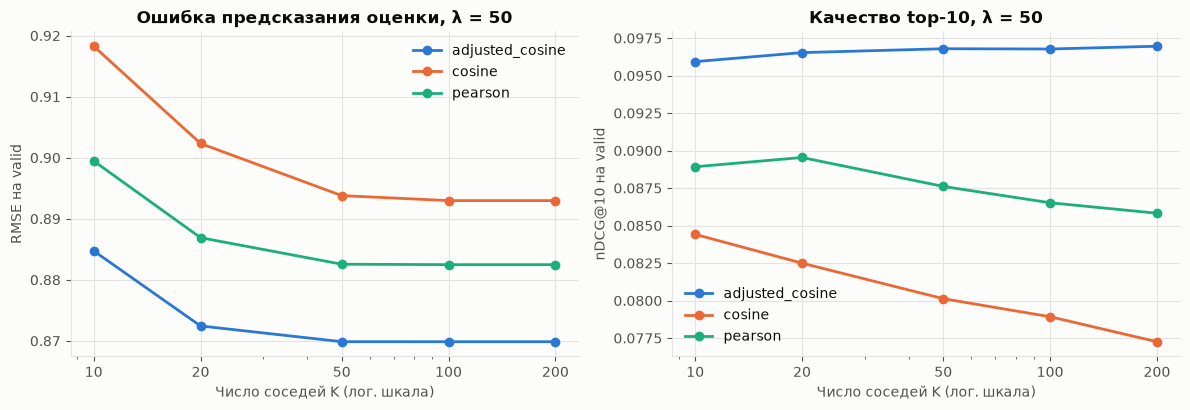

In [24]:
fig = plots.plot_item_cf_grid(item_cf_grid, config.ITEM_CF_SHRINKAGE)
plt.show()

Adjusted cosine лучше cosine и Pearson при всех λ и K: учёт смещения пользователя снижает RMSE на 0.02–0.04 и повышает nDCG@10 на 0.01–0.02 относительно cosine. Shrinkage улучшает top-N (nDCG@10 0.0948 → 0.0968 при λ = 0 → 50, K = 100) и ухудшает RMSE (0.858 → 0.870), λ = 100 хуже λ = 50 по обеим метрикам. Выбор по nDCG@10: adjusted cosine, λ = 50, K = 50 (0.0968; K = 200 даёт 0.0970 при меньшем Coverage@10). RMSE не меняется при K ≥ 50: у пользователя в train_inner в среднем 72 оценки, и большее K почти не расширяет множество соседей.

In [25]:
rows = []
for kind in ("adjusted_cosine", "pearson"):
    for use_negative, centered in ((False, True), (True, True), (True, False)):
        model = ItemCF(
            kind,
            shrinkage=config.ITEM_CF_SHRINKAGE,
            centered=centered,
            use_negative=use_negative,
        ).fit(inner.train)
        for k in (20, 50, 100):
            model.set_n_neighbors(k)
            prediction = model.predict(valid_users, valid_books)
            rows.append(
                {
                    "similarity": kind,
                    "variant": f"negative={use_negative}, centered={centered}",
                    "k": k,
                    "rmse": metrics.rmse(valid_ratings, prediction),
                }
            )
pd.DataFrame(rows).pivot_table(index=["similarity", "variant"], columns="k", values="rmse")

k                                                20     50     100
similarity      variant                                           
adjusted_cosine negative=False, centered=True 0.8724 0.8699 0.8699
                negative=True, centered=False 2.4801 2.6115 2.6279
                negative=True, centered=True  0.8690 0.8626 0.8623
pearson         negative=False, centered=True 0.8869 0.8826 0.8825
                negative=True, centered=False 1.0338 1.0670 1.0722
                negative=True, centered=True  0.8857 0.8806 0.8804

Без центрирования отрицательные схожести ломают предсказание (RMSE 2.5–2.6 для adjusted cosine): слагаемое s·r_uj при s < 0 вычитает сырую оценку. С центрированием их учёт снижает RMSE с 0.870 до 0.862 (K ≥ 50), но удваивает объём матрицы схожести и не влияет на top-N, где используются только положительные соседи. Основной вариант — положительные схожести; при них формулы с центрированием и без совпадают.

In [26]:
ranking_models = [item_cf] + [
    ItemCF(ranking="rating", min_support=support).fit(inner.train) for support in (1, 5, 10, 20)
]
pd.concat([evaluation.evaluate(model, valid_set, ks=(10,)) for model in ranking_models])[columns]

,,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
model,k,,,,,,,
"Item-CF[adjusted_cosine, K=50, λ=50, similarity]",10,0.0842,0.0734,0.0968,0.4265,0.4086,10.8430,0.0000
"Item-CF[adjusted_cosine, K=50, λ=50, rating, support=1]",10,0.0036,0.0029,0.0038,0.0319,0.9562,14.0606,0.0000
"Item-CF[adjusted_cosine, K=50, λ=50, rating, support=5]",10,0.0178,0.0167,0.0198,0.1368,0.9372,13.8026,0.0009
"Item-CF[adjusted_cosine, K=50, λ=50, rating, support=10]",10,0.0331,0.0288,0.0374,0.2298,0.8549,12.8232,0.1446
"Item-CF[adjusted_cosine, K=50, λ=50, rating, support=20]",10,0.0074,0.0055,0.0098,0.0449,0.2727,3.3413,0.9465


Ранжирование по предсказанной оценке уступает сумме схожестей в 2.6–25 раз по nDCG@10 (0.004–0.037 против 0.097): максимальную оценку получают книги с малым числом соседей и высокими оценками — нишевые книги (Novelty@10 до 14 бит). Порог поддержки частично это исправляет (лучший — 10 соседей), но при пороге 20 у 95 % пользователей список короче 10. Для top-N используется сумма схожестей с книгами, оценёнными на 4–5.

### 3.3. Сравнение на valid

In [27]:
user_mean = inner.train.groupby("user_id")["rating"].mean()
item_mean = inner.train.groupby("book_id")["rating"].mean()
start = time.perf_counter()
item_cf_prediction = item_cf.predict(valid_users, valid_books)
item_cf_predict_seconds = time.perf_counter() - start
rating_baselines = {
    "global mean": np.full(valid_ratings.size, inner.train["rating"].mean()),
    "user mean": user_mean.reindex(valid_users).to_numpy(),
    "item mean": item_mean.reindex(valid_books).to_numpy(),
    item_cf.name: item_cf_prediction,
}
pd.DataFrame(
    {
        name: {"rmse": metrics.rmse(valid_ratings, pred), "mae": metrics.mae(valid_ratings, pred)}
        for name, pred in rating_baselines.items()
    }
).T

,rmse,mae
global mean,0.9880,0.7594
user mean,0.9052,0.7049
item mean,0.9517,0.7567
"Item-CF[adjusted_cosine, K=50, λ=50, similarity]",0.8699,0.6541


In [28]:
item_cf_valid = evaluation.evaluate(item_cf, valid_set)
valid_comparison = pd.concat([valid_comparison, item_cf_valid])
valid_comparison.xs(10, level="k")[columns]

,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
model,,,,,,,
"Popularity[mean, m=7000]",0.0386,0.0323,0.0417,0.2134,0.0040,8.4578,0.0000
"Popularity[weighted, m=100000]",0.0386,0.0323,0.0441,0.2038,0.0039,8.3973,0.0000
Popularity[count],0.0348,0.0291,0.0383,0.2076,0.0047,8.1939,0.0000
Content-Based[tags=all],0.0474,0.0411,0.0536,0.2943,0.4881,12.1374,0.0000
"Item-CF[adjusted_cosine, K=50, λ=50, similarity]",0.0842,0.0734,0.0968,0.4265,0.4086,10.8430,0.0000


In [29]:
item_cf_valid

precision  recall   ndcg  \
model                                            k                              
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5      0.0980  0.0433 0.1033   
                                                 10     0.0842  0.0734 0.0968   
                                                 20     0.0690  0.1180 0.1083   

                                                       map  hit_rate  \
model                                            k                     
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5  0.0665    0.3020   
                                                 10 0.0489    0.4265   
                                                 20 0.0463    0.5865   

                                                     coverage  novelty  \
model                                            k                       
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5     0.3167  10.7975   
                                                 10    0.4086  10.8430   
                                                 20    0.5188  10.9287   

                                                     mean_popularity  \
model                                            k                     
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5         5048.0679   
                                                 10        4802.7735   
                                                 20        4400.9423   

                                                     short_lists  seconds  
model                                            k                         
Item-CF[adjusted_cosine, K=50, λ=50, similarity] 5        0.0000   1.6464  
                                                 10       0.0000   1.6464  
                                                 20       0.0000   1.6464

Item-CF — лучшая модель на valid: nDCG@10 0.097 против 0.054 у Content-Based (+81 %) и 0.044 у лучшего варианта Popularity, HitRate@10 — 42.7 %. Coverage@10 (40.9 %) ниже, чем у Content-Based (48.8 %), средняя популярность рекомендаций — 4 803 оценки против 2 227. RMSE 0.870 — на 3.9 % ниже предсказания средним пользователя (0.905).

### 3.4. Примеры выдачи

In [30]:
pd.concat(
    {
        dataset.books.loc[book_id - 1, "title"]: item_cf.get_similar_books(
            book_id, dataset.books, n=5
        )
        for book_id in queries
    },
    names=["query", "rank"],
)

book_id  \
query                                              rank            
Harry Potter and the Sorcerer's Stone (Harry Po... 0          18   
                                                   1          23   
                                                   2          24   
                                                   3          27   
                                                   4          25   
The Hunger Games (The Hunger Games, #1)            0          17   
                                                   1           2   
                                                   2          20   
                                                   3          31   
                                                   4          25   
Pride and Prejudice                                0          76   
                                                   1          43   
                                                   2         171   
                                                   3         230   
                                                   4           4   
The Hobbit                                         0          19   
                                                   1         155   
                                                   2         161   
                                                   3         189   
                                                   4         466   

                                                                                                     title  \
query                                              rank                                                      
Harry Potter and the Sorcerer's Stone (Harry Po... 0     Harry Potter and the Prisoner of Azkaban (Harr...   
                                                   1     Harry Potter and the Chamber of Secrets (Harry...   
                                                   2     Harry Potter and the Goblet of Fire (Harry Pot...   
                                                   3     Harry Potter and the Half-Blood Prince (Harry ...   
                                                   4     Harry Potter and the Deathly Hallows (Harry Po...   
The Hunger Games (The Hunger Games, #1)            0                  Catching Fire (The Hunger Games, #2)   
                                                   1     Harry Potter and the Sorcerer's Stone (Harry P...   
                                                   2                     Mockingjay (The Hunger Games, #3)   
                                                   3                                              The Help   
                                                   4     Harry Potter and the Deathly Hallows (Harry Po...   
Pride and Prejudice                                0                                 Sense and Sensibility   
                                                   1                                             Jane Eyre   
                                                   2                                                  Emma   
                                                   3                                            Persuasion   
                                                   4                                 To Kill a Mockingbird   
The Hobbit                                         0     The Fellowship of the Ring (The Lord of the Ri...   
                                                   1            The Two Towers (The Lord of the Rings, #2)   
                                                   2     The Return of the King (The Lord of the Rings,...   
                                                   3     The Lord of the Rings (The Lord of the Rings, ...   
                                                   4                             The Hobbit: Graphic Novel   

                                                                                                   authors  \
query                        

In [31]:
example_user = int(valid_set.user_ids[0])
history = (
    inner.train[inner.train["user_id"] == example_user]
    .merge(dataset.books[["book_id", "title"]], on="book_id")
    .sort_values("rating", ascending=False)
)
display(history.head(10)[["book_id", "title", "rating"]])
item_cf.get_recommendations(example_user, dataset.books, n=5, exclude=valid_set.seen)

,book_id,title,rating
0,258,The Shadow of the Wind (The Cemetery of Forgot...,5
29,1521,"Antigone (The Theban Plays, #3)",5
30,70,"Ender's Game (Ender's Saga, #1)",5
40,2002,The Death of Ivan Ilych,5
20,35,The Alchemist,5
43,1041,The Idiot,5
17,136,Divine Secrets of the Ya-Ya Sisterhood,5
44,45,Life of Pi,5
15,1644,Peace Like a River,5
14,11,The Kite Runner,5


,book_id,title,authors,score
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,0.5443
1,76,Sense and Sensibility,"Jane Austen, Tony Tanner, Ros Ballaster",0.5127
2,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",0.4867
3,25,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré",0.4796
4,14,Animal Farm,George Orwell,0.4551


Похожие по оценкам книги — продолжения серий и книги того же автора, а также популярные книги с общей аудиторией (для «The Hunger Games» — «Harry Potter», «The Help»): схожесть отражает совместное чтение, а не содержание. Рекомендации примера — книги из head каталога, хотя история пользователя состоит из классики и современной прозы.

### 3.5. Время и память

In [32]:
pd.Series(
    {
        "fit_seconds": item_cf_fit_seconds,
        "predict_valid_pairs": valid_ratings.size,
        "predict_seconds": item_cf_predict_seconds,
        "top20_users": valid_set.user_ids.size,
        "top20_seconds": item_cf_valid["seconds"].iloc[0],
    }
).to_frame("value")

,value
fit_seconds,12.1999
predict_valid_pairs,956230.0000
predict_seconds,3.5897
top20_users,10000.0000
top20_seconds,1.6464


Обучение (схожесть и top-K соседи) — 12 с, предсказание 956 тыс. оценок — 3.5 с, top-20 для 10 000 пользователей — 1.7 с. Пик памяти при обучении — 1.15 ГБ (плотные блоки схожести и промежуточные разреженные произведения).

## 4. Matrix Factorization (SVD)

### 4.1. FunkSVD: подбор параметров на valid

In [33]:
from recsys.models import FunkSVD, PureSVD
from recsys.models.svd import baseline_predict

rows = []
for n_factors in (50, 100, 150):
    for n_epochs in (20, 30):
        for reg_all in (0.02, 0.05):
            start = time.perf_counter()
            model = FunkSVD(n_factors, n_epochs, config.SVD_LR_ALL, reg_all).fit(inner.train)
            fit_seconds = time.perf_counter() - start
            prediction = model.predict(valid_users, valid_books)
            result = evaluation.evaluate(model, valid_set, ks=(10,)).iloc[0]
            rows.append(
                {
                    "n_factors": n_factors,
                    "n_epochs": n_epochs,
                    "reg_all": reg_all,
                    "fit_seconds": fit_seconds,
                    "rmse": metrics.rmse(valid_ratings, prediction),
                    "mae": metrics.mae(valid_ratings, prediction),
                    **result[columns],
                }
            )
            if (n_factors, n_epochs, reg_all) == (
                config.SVD_N_FACTORS,
                config.SVD_N_EPOCHS,
                config.SVD_REG_ALL,
            ):
                svd, svd_fit_seconds = model, fit_seconds
svd_grid = pd.DataFrame(rows)
svd_grid.sort_values("rmse")

,n_factors,n_epochs,reg_all,fit_seconds,rmse,mae,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
7,100,30,0.0500,56.3579,0.8486,0.6590,0.0019,0.0017,0.0019,0.0151,0.0439,14.9290,0.0000
11,150,30,0.0500,67.9924,0.8489,0.6595,0.0020,0.0017,0.0021,0.0161,0.0557,14.9276,0.0000
3,50,30,0.0500,39.5818,0.8497,0.6597,0.0016,0.0013,0.0016,0.0130,0.0293,14.9758,0.0000
5,100,20,0.0500,39.2812,0.8551,0.6645,0.0011,0.0010,0.0012,0.0091,0.0128,14.9748,0.0000
9,150,20,0.0500,44.7309,0.8552,0.6647,0.0014,0.0010,0.0014,0.0111,0.0207,14.9445,0.0000
1,50,20,0.0500,25.2741,0.8565,0.6654,0.0011,0.0009,0.0012,0.0090,0.0071,15.0168,0.0000
0,50,20,0.0200,22.9351,0.8574,0.6638,0.0038,0.0032,0.0038,0.0284,0.0710,14.4928,0.0000
4,100,20,0.0200,38.9607,0.8602,0.6661,0.0037,0.0033,0.0039,0.0303,0.1223,14.3283,0.0000
8,150,20,0.0200,47.7074,0.8633,0.6690,0.0042,0.0036,0.0045,0.0328,0.1677,14.2549,0.0000
2,50,30,0.0200,39.2976,0.8676,0.6691,0.0054,0.0046,0.0059,0.0462,0.2216,13.7260,0.0000


Минимальный RMSE — n_factors = 100, 30 эпох, reg_all = 0.05: 0.8486. При reg_all = 0.02 рост числа эпох с 20 до 30 повышает RMSE (0.860 → 0.871 при 100 факторах) — переобучение; при reg_all = 0.05 — снижает (0.855 → 0.849). Число факторов влияет слабее: при 30 эпохах и reg_all = 0.05 разброс RMSE — 0.001. nDCG@10 при любых параметрах не превышает 0.006.

### 4.2. Ошибка предсказания оценки

In [34]:
start = time.perf_counter()
svd_prediction = svd.predict(valid_users, valid_books)
svd_predict_seconds = time.perf_counter() - start
rating_baselines["BaselineOnly"] = baseline_predict(inner.train, valid_users, valid_books)
rating_baselines[svd.name] = svd_prediction
pd.DataFrame(
    {
        name: {"rmse": metrics.rmse(valid_ratings, pred), "mae": metrics.mae(valid_ratings, pred)}
        for name, pred in rating_baselines.items()
    }
).T.sort_values("rmse")

,rmse,mae
"SVD[f=100, epochs=30, lr=0.005, reg=0.05, min_ratings=1]",0.8486,0.6590
BaselineOnly,0.8630,0.6746
"Item-CF[adjusted_cosine, K=50, λ=50, similarity]",0.8699,0.6541
user mean,0.9052,0.7049
item mean,0.9517,0.7567
global mean,0.9880,0.7594


FunkSVD — наименьший RMSE: 0.849 против 0.863 у BaselineOnly (μ + b_u + b_i) и 0.870 у Item-CF; по MAE Item-CF точнее (0.654 против 0.659). Латентные факторы снижают RMSE относительно модели смещений на 1.7 %.

### 4.3. Top-N по предсказанной оценке

In [35]:
rows = []
for min_ratings in (1, 100, 500, 1000, 2000, 5000):
    svd.set_min_item_ratings(min_ratings)
    result = evaluation.evaluate(svd, valid_set, ks=(10,)).iloc[0]
    rows.append(
        {
            "min_item_ratings": min_ratings,
            "n_candidates": int(svd.candidates.sum()),
            **result[columns + ["mean_popularity"]],
        }
    )
svd.set_min_item_ratings(config.SVD_MIN_ITEM_RATINGS)
pd.DataFrame(rows)

,min_item_ratings,n_candidates,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists,mean_popularity
0,1,10000,0.0019,0.0017,0.0019,0.0151,0.0439,14.9290,0.0000,232.2153
1,100,6742,0.0029,0.0025,0.0030,0.0226,0.0494,14.1396,0.0000,381.9613
2,500,1520,0.0125,0.0104,0.0116,0.0854,0.0512,11.5172,0.0000,2360.1119
3,1000,720,0.0200,0.0168,0.0192,0.1217,0.0375,10.4685,0.0000,4316.9895
4,2000,307,0.0282,0.0234,0.0301,0.1611,0.0227,9.4659,0.0000,6797.4879
5,5000,81,0.0366,0.0303,0.0412,0.1993,0.0078,8.6325,0.0000,10220.9185


In [36]:
top_bias = np.argsort(-svd.item_bias)[:10]
dataset.books.loc[top_bias, ["book_id", "title"]].assign(
    item_bias=svd.item_bias[top_bias], n_ratings=svd.item_counts[top_bias]
)

,book_id,title,item_bias,n_ratings
8945,8946,The Divan,0.9925,50
3627,3628,The Complete Calvin and Hobbes,0.9535,293
9565,9566,Attack of the Deranged Mutant Killer Monster S...,0.9314,79
6919,6920,The Indispensable Calvin and Hobbes,0.8970,110
7946,7947,ESV Study Bible,0.8657,53
6589,6590,The Authoritative Calvin and Hobbes: A Calvin ...,0.8525,118
7253,7254,Homicidal Psycho Jungle Cat: A Calvin and Hobb...,0.8392,108
8977,8978,The Revenge of the Baby-Sat,0.8314,96
8108,8109,"The Absolute Sandman, Volume One",0.8298,94
861,862,"Words of Radiance (The Stormlight Archive, #2)",0.8187,574


Без ограничения кандидатов top-10 состоит из книг с малым числом оценок и большим b_i: средняя популярность рекомендаций — 232 оценки, nDCG@10 — 0.002. Среди 10 книг с наибольшим b_i 6 — сборники «Calvin and Hobbes», у 9 — менее 300 оценок. Порог числа оценок повышает nDCG@10 до 0.041 (5 000 оценок), но сводит выдачу к 81 популярной книге (Coverage@10 0.8 %) — уровень Popularity без выигрыша от персонализации.

### 4.4. PureSVD

In [37]:
rows = []
for n_factors in (20, 50, 100, 200, 300, 500):
    start = time.perf_counter()
    model = PureSVD(n_factors).fit(inner.train)
    fit_seconds = time.perf_counter() - start
    result = evaluation.evaluate(model, valid_set, ks=(10,)).iloc[0]
    rows.append({"n_factors": n_factors, "fit_seconds": fit_seconds, **result[columns]})
    if n_factors == config.PURE_SVD_N_FACTORS:
        pure_svd, pure_svd_fit_seconds = model, fit_seconds
pure_svd_grid = pd.DataFrame(rows)
pure_svd_grid

,n_factors,fit_seconds,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists
0,20,1.8951,0.0581,0.0500,0.0655,0.3610,0.0508,9.4129,0.0000
1,50,1.7096,0.0631,0.0544,0.0711,0.3810,0.0910,9.9382,0.0000
2,100,3.0941,0.0637,0.0547,0.0722,0.3842,0.1381,10.4840,0.0000
3,200,5.6471,0.0646,0.0552,0.0733,0.3893,0.1963,11.1217,0.0000
4,300,10.0318,0.0651,0.0556,0.0733,0.3833,0.2503,11.5144,0.0000
5,500,21.9130,0.0627,0.0546,0.0711,0.3691,0.3342,12.1087,0.0000


nDCG@10 растёт с рангом до k = 200 (0.0733), при k = 300 не меняется, при k = 500 снижается до 0.071; Coverage@10 растёт монотонно (5 % → 33 %). Выбран k = 200: обучение 5.7 с против 9.8 с при k = 300.

### 4.5. Сравнение на valid

In [38]:
svd_valid = evaluation.evaluate(svd, valid_set)
pure_svd_valid = evaluation.evaluate(pure_svd, valid_set)
valid_comparison = pd.concat([valid_comparison, svd_valid, pure_svd_valid])
valid_comparison.xs(10, level="k")[columns + ["map", "mean_popularity"]]

,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists,map,mean_popularity
model,,,,,,,,,
"Popularity[mean, m=7000]",0.0386,0.0323,0.0417,0.2134,0.0040,8.4578,0.0000,0.0208,11352.2268
"Popularity[weighted, m=100000]",0.0386,0.0323,0.0441,0.2038,0.0039,8.3973,0.0000,0.0219,11839.1849
Popularity[count],0.0348,0.0291,0.0383,0.2076,0.0047,8.1939,0.0000,0.0159,13296.4809
Content-Based[tags=all],0.0474,0.0411,0.0536,0.2943,0.4881,12.1374,0.0000,0.0238,2226.5077
"Item-CF[adjusted_cosine, K=50, λ=50, similarity]",0.0842,0.0734,0.0968,0.4265,0.4086,10.8430,0.0000,0.0489,4802.7735
"SVD[f=100, epochs=30, lr=0.005, reg=0.05, min_ratings=1]",0.0019,0.0017,0.0019,0.0151,0.0439,14.9290,0.0000,0.0007,232.2153
PureSVD[k=200],0.0646,0.0552,0.0733,0.3893,0.1963,11.1217,0.0000,0.0325,2264.7288


PureSVD — вторая модель по точности на valid: nDCG@10 0.073 против 0.097 у Item-CF и 0.054 у Content-Based. FunkSVD уступает всем моделям, включая Popularity (nDCG@10 0.002). PureSVD восстанавливает матрицу, где неоценённые книги равны 0, и учитывает сам факт оценки; FunkSVD обучается только на наблюдаемых оценках и не отличает непрочитанные книги от прочитанных.

### 4.6. Примеры выдачи

In [39]:
display(svd.get_recommendations(example_user, dataset.books, n=5, exclude=valid_set.seen))
pure_svd.get_recommendations(example_user, dataset.books, n=5, exclude=valid_set.seen)

,book_id,title,authors,predicted_rating
0,3628,The Complete Calvin and Hobbes,Bill Watterson,4.5304
1,6920,The Indispensable Calvin and Hobbes,Bill Watterson,4.5192
2,7254,Homicidal Psycho Jungle Cat: A Calvin and Hobb...,Bill Watterson,4.4884
3,9566,Attack of the Deranged Mutant Killer Monster S...,Bill Watterson,4.4624
4,8946,The Divan,Hafez,4.4573


,book_id,title,authors,score
0,172,Anna Karenina,"Leo Tolstoy, Louise Maude, Leo Tolstoj, Aylmer...",2.0813
1,114,Tuesdays with Morrie,"Mitch Albom, Saulius Dagys",2.0652
2,195,The Guernsey Literary and Potato Peel Pie Society,"Mary Ann Shaffer, Annie Barrows",1.6900
3,255,Atlas Shrugged,"Ayn Rand, Leonard Peikoff",1.3702
4,291,Cutting for Stone,Abraham Verghese,1.3128


Пользователю с историей из классической и современной прозы FunkSVD рекомендует сборники «Calvin and Hobbes» — книги с наибольшим b_i, не связанные с историей. PureSVD рекомендует популярную прозу, близкую к истории («Anna Karenina», «Cutting for Stone»).

### 4.7. Время

In [40]:
pd.Series(
    {
        "svd_fit_seconds": svd_fit_seconds,
        "svd_predict_seconds": svd_predict_seconds,
        "svd_top20_seconds": svd_valid["seconds"].iloc[0],
        "pure_svd_fit_seconds": pure_svd_fit_seconds,
        "pure_svd_top20_seconds": pure_svd_valid["seconds"].iloc[0],
    }
).to_frame("value")

,value
svd_fit_seconds,56.3579
svd_predict_seconds,0.2188
svd_top20_seconds,1.0663
pure_svd_fit_seconds,5.6471
pure_svd_top20_seconds,1.0657


FunkSVD: обучение 56 с (3.8 млн оценок, 100 факторов, 30 эпох), предсказание 956 тыс. оценок — 0.2 с, top-20 для 10 000 пользователей — 1.0 с. PureSVD: обучение 5.7 с, top-20 — 1.0 с.

## 5. Сравнение моделей на test

### 5.1. Обучение на train и формирование рекомендаций

In [41]:
test_set = evaluation.build_eval_set(outer.train, outer.test, n_users=None)
final_models = {
    "Popularity (mean)": Popularity("mean", config.POPULARITY_MIN_RATINGS_TRAIN),
    "Popularity (weighted)": Popularity("weighted", config.POPULARITY_WR_M),
    "Content-Based": ContentBased(dataset.books, book_tags),
    "Item-based CF": ItemCF(),
    "FunkSVD": FunkSVD(),
    "PureSVD": PureSVD(config.PURE_SVD_N_FACTORS),
}
fit_seconds = {}
for label, model in final_models.items():
    start = time.perf_counter()
    model.fit(outer.train)
    fit_seconds[label] = time.perf_counter() - start
test_recs, recommend_seconds = evaluation.recommend_all(final_models, test_set)
pd.Series(
    {
        "eval_users": test_set.user_ids.size,
        "n_relevant_mean": test_set.n_relevant.mean(),
        "n_relevant_median": float(pd.Series(test_set.n_relevant).median()),
        "catalog_in_train": test_set.n_catalog,
        "popularity_mean_pool": final_models["Popularity (mean)"].n_candidates,
    }
).to_frame("value")

,value
eval_users,53300.0000
n_relevant_mean,15.3216
n_relevant_median,15.0000
catalog_in_train,10000.0000
popularity_mean_pool,42.0000


In [42]:
pd.DataFrame({"fit_seconds": fit_seconds, "top20_seconds": recommend_seconds})

,fit_seconds,top20_seconds
Popularity (mean),0.0522,6.4283
Popularity (weighted),0.0517,7.1384
Content-Based,0.1951,42.2533
Item-based CF,15.0840,9.1732
FunkSVD,65.0121,5.6004
PureSVD,6.5946,5.3286


Оценка — все 53 300 пользователей с релевантными книгами в test, без выборки. Порог Popularity (mean) масштабирован до m = 8 750 (пул 42 книги; у 0.1 % пользователей top-10 короче 10 позиций, при K = 20 — у 4.2 %). Top-20 для 53 300 пользователей — 5.4–41 с; Content-Based медленнее остальных из-за произведения разреженных профилей на матрицу TF-IDF.

### 5.2. Сводная таблица и графики

In [43]:
test_table = evaluation.compare_recommendations(test_recs, test_set)
test_table.xs(10, level="k")[columns + ["map", "mean_popularity"]]

,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists,map,mean_popularity
model,,,,,,,,,
Popularity (mean),0.0403,0.0267,0.0431,0.2180,0.0042,8.5049,0.0011,0.0216,13560.9806
Popularity (weighted),0.0395,0.0261,0.0440,0.2103,0.0044,8.5490,0.0000,0.0216,13319.5196
Content-Based,0.0504,0.0351,0.0553,0.3112,0.6324,12.1640,0.0000,0.0242,2526.6933
Item-based CF,0.0858,0.0584,0.0950,0.4288,0.5223,10.9554,0.0000,0.0472,5457.2294
FunkSVD,0.0034,0.0023,0.0032,0.0266,0.1049,14.8608,0.0000,0.0011,360.3981
PureSVD,0.0670,0.0455,0.0731,0.4050,0.2383,11.1467,0.0000,0.0314,2790.2986


In [44]:
test_table.pivot_table(index="model", columns="k", values=["ndcg", "recall", "precision"], sort=False)

ndcg               recall               precision  \
k                         5      10     20     5      10     20        5    
model                                                                       
Popularity (mean)     0.0455 0.0431 0.0435 0.0145 0.0267 0.0436    0.0440   
Popularity (weighted) 0.0495 0.0440 0.0435 0.0158 0.0261 0.0416    0.0475   
Content-Based         0.0590 0.0553 0.0580 0.0202 0.0351 0.0590    0.0570   
Item-based CF         0.1032 0.0950 0.0976 0.0340 0.0584 0.0965    0.0983   
FunkSVD               0.0027 0.0032 0.0041 0.0011 0.0023 0.0049    0.0030   
PureSVD               0.0784 0.0731 0.0765 0.0260 0.0455 0.0769    0.0756   

                                     
k                         10     20  
model                                
Popularity (mean)     0.0403 0.0326  
Popularity (weighted) 0.0395 0.0314  
Content-Based         0.0504 0.0431  
Item-based CF         0.0858 0.0717  
FunkSVD               0.0034 0.0037  
PureSVD               0.0670 0.0575

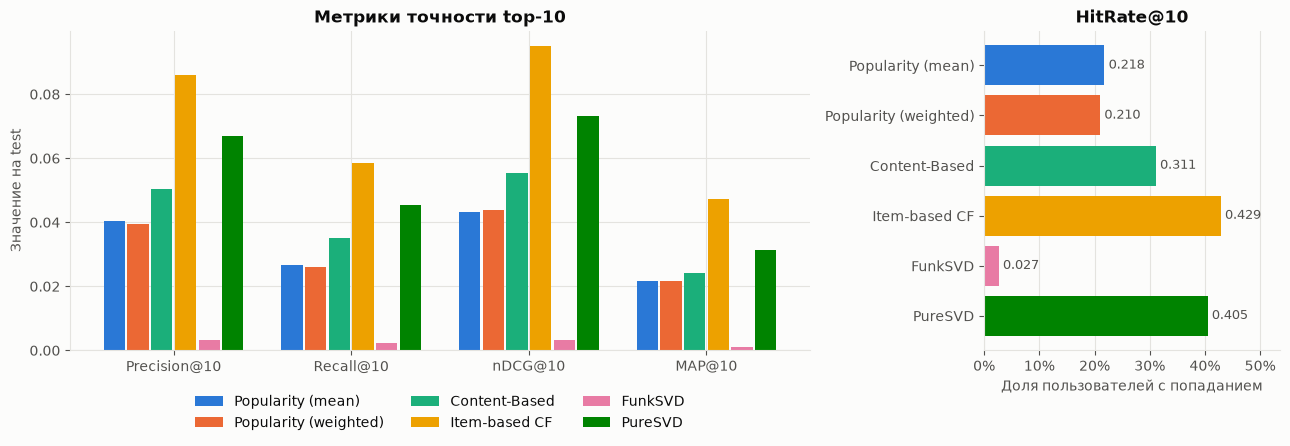

In [45]:
test_k10 = test_table.xs(10, level="k")
fig = plots.plot_model_comparison(test_k10)
plots.save_figure(fig, "model_comparison")
plt.show()

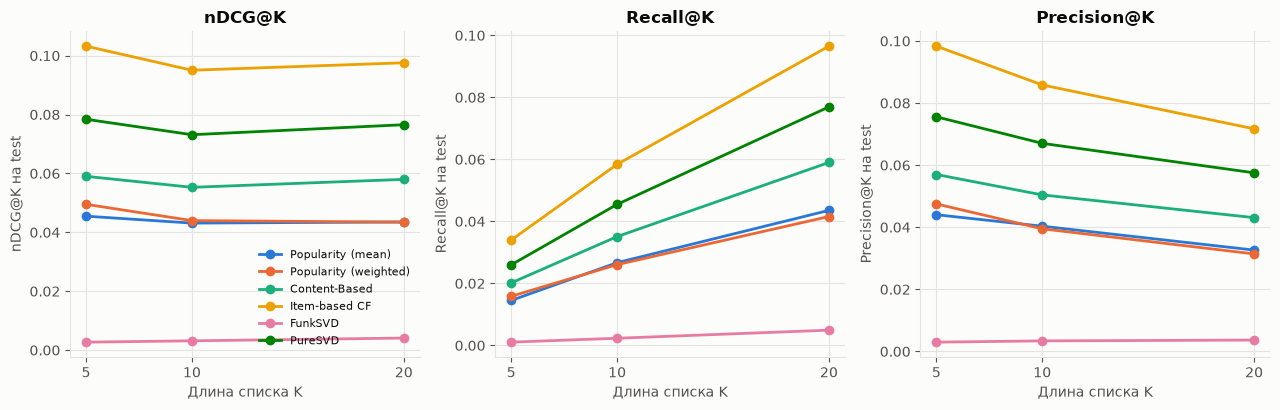

In [46]:
fig = plots.plot_metrics_by_k(test_table)
plots.save_figure(fig, "metrics_by_k")
plt.show()

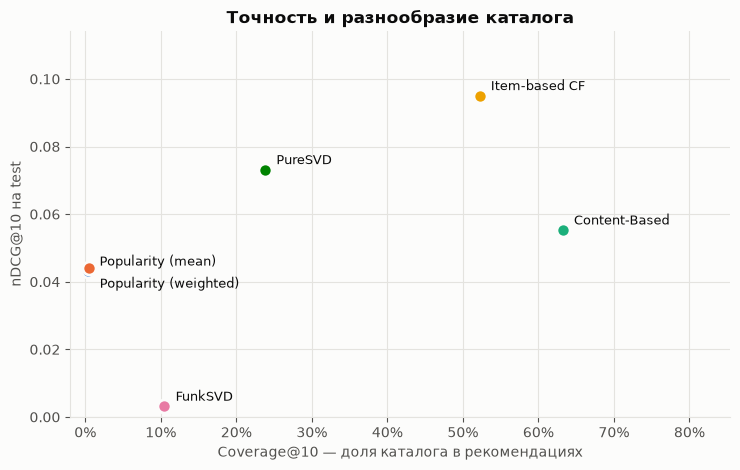

In [47]:
fig = plots.plot_coverage_vs_ndcg(test_k10)
plots.save_figure(fig, "coverage_vs_ndcg")
plt.show()

In [48]:
valid_ndcg = valid_comparison.xs(10, level="k")["ndcg"]
valid_ndcg.index = [
    "Popularity (mean)", "Popularity (weighted)", "Popularity (count)", "Content-Based",
    "Item-based CF", "FunkSVD", "PureSVD",
]  # fmt: skip
pd.DataFrame({"valid": valid_ndcg, "test": test_k10["ndcg"]}).dropna()

,valid,test
Content-Based,0.0536,0.0553
FunkSVD,0.0019,0.0032
Item-based CF,0.0968,0.0950
Popularity (mean),0.0417,0.0431
Popularity (weighted),0.0441,0.0440
PureSVD,0.0733,0.0731


Порядок моделей на test совпадает с valid при всех K: Item-based CF (nDCG@10 0.095) > PureSVD (0.073) > Content-Based (0.055) > Popularity (0.043–0.044) > FunkSVD (0.003). Отклонение nDCG@10 от valid — не более 0.002. Для Popularity nDCG@K почти не растёт с K, для персонализированных моделей Recall@20 в 1.6–1.7 раза выше Recall@10. Content-Based даёт наибольший Coverage@10 (63.2 %), Item-based CF — 52.2 % при максимальной точности; Coverage выше, чем на valid, так как оценивается 53 300 пользователей вместо 10 000.

### 5.3. Ошибка предсказания оценки

In [49]:
test_users = outer.test["user_id"].to_numpy()
test_books = outer.test["book_id"].to_numpy()
test_ratings = outer.test["rating"].to_numpy()
train_user_mean = outer.train.groupby("user_id")["rating"].mean()
train_item_mean = outer.train.groupby("book_id")["rating"].mean()
test_predictions = {
    "global mean": np.full(test_ratings.size, outer.train["rating"].mean()),
    "item mean": train_item_mean.reindex(test_books).to_numpy(),
    "user mean": train_user_mean.reindex(test_users).to_numpy(),
    "BaselineOnly": baseline_predict(outer.train, test_users, test_books),
    "Item-based CF": final_models["Item-based CF"].predict(test_users, test_books),
    "FunkSVD": final_models["FunkSVD"].predict(test_users, test_books),
}
test_rmse = pd.DataFrame(
    {
        name: {"rmse": metrics.rmse(test_ratings, pred), "mae": metrics.mae(test_ratings, pred)}
        for name, pred in test_predictions.items()
    }
).T
test_rmse

,rmse,mae
global mean,0.9743,0.7499
item mean,0.9381,0.7448
user mean,0.9029,0.7039
BaselineOnly,0.8584,0.6694
Item-based CF,0.8616,0.6519
FunkSVD,0.8438,0.6550


На test FunkSVD сохраняет наименьший RMSE (0.844; на 1.7 % ниже BaselineOnly, на 2.1 % ниже Item-based CF), Item-based CF — наименьший MAE (0.652).

### 5.4. Влияние выборки пользователей

In [50]:
sample_set = evaluation.build_eval_set(outer.train, outer.test)
sample_recs = {
    label: evaluation.align_rows(recs, test_set, sample_set) for label, recs in test_recs.items()
}
sample_k10 = evaluation.compare_recommendations(sample_recs, sample_set, ks=(10,)).xs(10, level="k")
pd.DataFrame(
    {
        "ndcg_all": test_k10["ndcg"],
        "ndcg_10k": sample_k10["ndcg"],
        "coverage_all": test_k10["coverage"],
        "coverage_10k": sample_k10["coverage"],
    }
)

,ndcg_all,ndcg_10k,coverage_all,coverage_10k
model,,,,
Popularity (mean),0.0431,0.0430,0.0042,0.0042
Popularity (weighted),0.0440,0.0438,0.0044,0.0038
Content-Based,0.0553,0.0556,0.6324,0.4649
Item-based CF,0.0950,0.0935,0.5223,0.4002
FunkSVD,0.0032,0.0029,0.1049,0.0545
PureSVD,0.0731,0.0734,0.2383,0.2069


На выборке 10 000 пользователей nDCG@10 отличается от полного набора не более чем на 0.0015, порядок моделей тот же — выборка на valid достаточна для подбора параметров. Coverage@10 зависит от числа пользователей (Content-Based: 46.5 % против 63.2 %), поэтому сравнивается только при одинаковом наборе.

### 5.5. Сегменты активности пользователей

In [51]:
activity = eda.activity_segment(ratings)
test_segments = evaluation.segment_metrics(test_recs, test_set, activity)
test_segments[["n_users", "n_relevant", "ndcg", "ndcg_ci", "recall", "hit_rate", "hit_rate_ci"]]

n_users  n_relevant   ndcg  ndcg_ci  recall  \
model                 segment                                                
Popularity (mean)     <50          882      4.9705 0.0275   0.0074  0.0335   
                      50–99      15387     12.3318 0.0348   0.0017  0.0264   
                      100–149    32802     16.2629 0.0459   0.0013  0.0268   
                      ≥150        4229     21.0579 0.0555   0.0040  0.0253   
Popularity (weighted) <50          882      4.9705 0.0283   0.0070  0.0319   
                      50–99      15387     12.3318 0.0359   0.0017  0.0256   
                      100–149    32802     16.2629 0.0466   0.0013  0.0262   
                      ≥150        4229     21.0579 0.0564   0.0039  0.0254   
Content-Based         <50          882      4.9705 0.0959   0.0111  0.1156   
                      50–99      15387     12.3318 0.0562   0.0018  0.0414   
                      100–149    32802     16.2629 0.0544   0.0012  0.0315   
                      ≥150        4229     21.0579 0.0504   0.0031  0.0236   
Item-based CF         <50          882      4.9705 0.1091   0.0121  0.1256   
                      50–99      15387     12.3318 0.0913   0.0025  0.0661   
                      100–149    32802     16.2629 0.0959   0.0017  0.0546   
                      ≥150        4229     21.0579 0.0993   0.0047  0.0459   
FunkSVD               <50          882      4.9705 0.0010   0.0010  0.0011   
                      50–99      15387     12.3318 0.0022   0.0003  0.0020   
                      100–149    32802     16.2629 0.0035   0.0003  0.0024   
                      ≥150        4229     21.0579 0.0045   0.0010  0.0028   
PureSVD               <50          882      4.9705 0.0660   0.0091  0.0767   
                      50–99      15387     12.3318 0.0685   0.0019  0.0500   
                      100–149    32802     16.2629 0.0751   0.0013  0.0438   
                      ≥150        4229     21.0579 0.0764   0.0035  0.0360   

                               hit_rate  hit_rate_ci  
model                 segment                         
Popularity (mean)     <50        0.0986       0.0197  
                      50–99      0.1741       0.0060  
                      100–149    0.2344       0.0046  
                      ≥150       0.2757       0.0135  
Popularity (weighted) <50        0.0918       0.0191  
                      50–99      0.1665       0.0059  
                      100–149    0.2258       0.0045  
                      ≥150       0.2734       0.0134  
Content-Based         <50        0.3413       0.0313  
                      50–99      0.3095       0.0073  
                      100–149    0.3113       0.0050  
                      ≥150       0.3095       0.0139  
Item-based CF         <50        0.3810       0.0321  
                      50–99      0.4078       0.0078  
                      100–149    0.4360       0.0054  
                      ≥150       0.4594       0.0150  
FunkSVD               <50        0.0057       0.0050  
                      50–99      0.0191       0.0022  
                      100–149    0.0294       0.0018  
                      ≥150       0.0359       0.0056  
PureSVD               <50        0.2687       0.0293  
                      50–99      0.3706       0.0076  
                      100–149    0.4185       0.0053  
                      ≥150       0.4538       0.0150

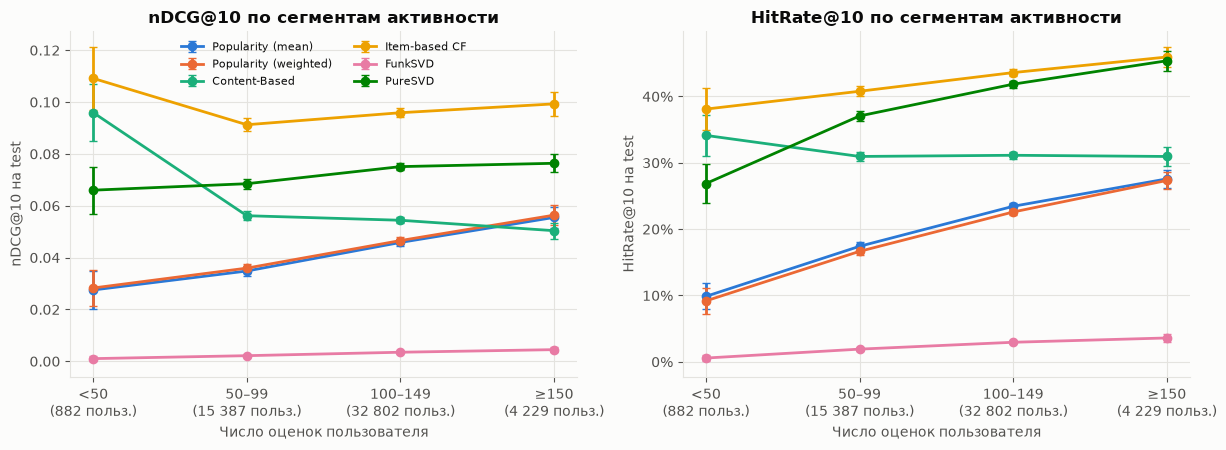

segment,<50,50–99,100–149,≥150,ratio_top_to_low
model,,,,,
Popularity (mean),0.0986,0.1741,0.2344,0.2757,2.7952
Popularity (weighted),0.0918,0.1665,0.2258,0.2734,2.9765
Content-Based,0.3413,0.3095,0.3113,0.3095,0.9070
Item-based CF,0.3810,0.4078,0.4360,0.4594,1.2060
FunkSVD,0.0057,0.0191,0.0294,0.0359,6.3402
PureSVD,0.2687,0.3706,0.4185,0.4538,1.6887


In [52]:
fig = plots.plot_segment_metrics(test_segments)
plots.save_figure(fig, "segment_metrics")
plt.show()
hit_rate = test_segments["hit_rate"].unstack("segment")
hit_rate.assign(ratio_top_to_low=hit_rate["≥150"] / hit_rate["<50"])

У пользователей сегмента `<50` в среднем 5.0 релевантных книг в test против 12–21 в остальных сегментах: при малом |rel| Recall@10 и nDCG@10 выше, HitRate@10 — ниже, поэтому модели сравниваются внутри сегмента. HitRate@10 сегмента `≥150` выше, чем `<50`: у Popularity в 2.8–3.0 раза, у PureSVD в 1.7 раза, у Item-based CF в 1.2 раза; у Content-Based не зависит от активности (0.31–0.34). В сегменте `<50` отставание Content-Based от Item-based CF по HitRate@10 — 10 % против 24–33 % в остальных сегментах.

### 5.6. Exposure: head и long tail

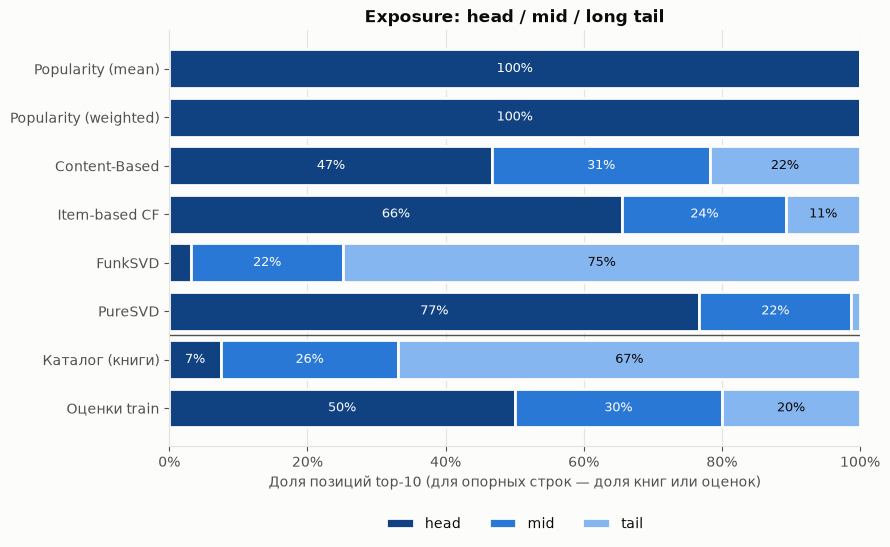

,head,mid,tail
Popularity (mean),1.0000,0.0000,0.0000
Popularity (weighted),1.0000,0.0000,0.0000
Content-Based,0.4679,0.3143,0.2178
Item-based CF,0.6561,0.2370,0.1069
FunkSVD,0.0315,0.2203,0.7482
PureSVD,0.7672,0.2203,0.0125
Каталог (книги),0.0745,0.2573,0.6682
Оценки train,0.5002,0.2998,0.2000


In [53]:
train_book_counts = eda.book_counts(outer.train)
book_segments = eda.popularity_segments(train_book_counts)
test_exposure = evaluation.exposure(test_recs, book_segments)
exposure_reference = pd.DataFrame(
    {
        "Каталог (книги)": book_segments.value_counts(normalize=True),
        "Оценки train": train_book_counts.groupby(book_segments, observed=False).sum()
        / train_book_counts.sum(),
    }
).T[test_exposure.columns]
fig = plots.plot_exposure(test_exposure, exposure_reference)
plots.save_figure(fig, "exposure")
plt.show()
pd.concat([test_exposure, exposure_reference])

Head (7.5 % книг, 50 % оценок train) занимает 100 % позиций top-10 Popularity, 77 % — PureSVD, 66 % — Item-based CF, 47 % — Content-Based. Long tail (66.8 % книг) получает 1.3 % позиций у PureSVD, 11 % у Item-based CF и 22 % у Content-Based. Content-Based ближе всех к распределению оценок train (50 / 30 / 20 %); Item-based CF и PureSVD усиливают popularity bias. FunkSVD отдаёт tail 75 % позиций при минимальной точности.

### 5.7. Чувствительность к порогу релевантности

In [54]:
strict_set = evaluation.build_eval_set(outer.train, outer.test, n_users=None, threshold=5)
strict_recs = {
    label: evaluation.align_rows(recs, test_set, strict_set) for label, recs in test_recs.items()
}
strict_k10 = evaluation.compare_recommendations(strict_recs, strict_set, ks=(10,)).xs(10, level="k")
threshold_table = pd.concat(
    {
        "rating ≥ 4": test_k10[["precision", "recall", "ndcg", "hit_rate"]],
        "rating = 5": strict_k10[["precision", "recall", "ndcg", "hit_rate"]],
    },
    axis=1,
)
threshold_table[("ratio", "ndcg")] = strict_k10["ndcg"] / test_k10["ndcg"]
print(f"Пользователей с оценкой 5 в test: {strict_set.user_ids.size}")
threshold_table

Пользователей с оценкой 5 в test: 49443


rating ≥ 4                        rating = 5         \
                       precision recall   ndcg hit_rate  precision recall   
model                                                                       
Popularity (mean)         0.0403 0.0267 0.0431   0.2180     0.0259 0.0355   
Popularity (weighted)     0.0395 0.0261 0.0440   0.2103     0.0260 0.0357   
Content-Based             0.0504 0.0351 0.0553   0.3112     0.0274 0.0387   
Item-based CF             0.0858 0.0584 0.0950   0.4288     0.0505 0.0714   
FunkSVD                   0.0034 0.0023 0.0032   0.0266     0.0030 0.0047   
PureSVD                   0.0670 0.0455 0.0731   0.4050     0.0366 0.0515   

                                       ratio  
                        ndcg hit_rate   ndcg  
model                                         
Popularity (mean)     0.0354   0.1464 0.8209  
Popularity (weighted) 0.0365   0.1456 0.8294  
Content-Based         0.0378   0.1833 0.6845  
Item-based CF         0.0711   0.2851 0.7476  
FunkSVD               0.0037   0.0235 1.1730  
PureSVD               0.0512   0.2447 0.6997

При пороге «= 5» оцениваются 49 443 пользователя; nDCG@10 всех моделей снижается на 17–32 %, порядок моделей сохраняется. Отрыв Content-Based от Popularity (weighted) сокращается с 26 % до 4 %, отрыв Item-based CF — с 2.2 до 1.9 раза: Content-Based чаще угадывает книги с оценкой 4, чем с оценкой 5.

## 6. Гибридная модель и cold start

### 6.1. Подбор n0 на valid

In [55]:
from recsys import cold_start
from recsys.models import Hybrid

N0_GRID = (0, 1, 2, 5, 10, 20, 50, 100)
valid_hybrid = Hybrid(item_cf, content, popularity_weighted).fit(inner.train, fit_components=False)
valid_full = cold_start.evaluate_models(
    {
        "Popularity (weighted)": popularity_weighted,
        "Content-Based": content,
        "Item-based CF": item_cf,
        "Hybrid": valid_hybrid,
    },
    valid_set,
    N0_GRID,
)
valid_cold_users = cold_start.sample_users(valid_set.user_ids)
valid_histories = cold_start.evaluate_histories(
    inner.train, valid_set, valid_cold_users, dataset.books, book_tags, n0_grid=N0_GRID,
    pure_svd=False,
)  # fmt: skip
valid_n0 = pd.concat([valid_histories, pd.concat({"все": valid_full}, names=["history"]).swaplevel()])
n0_table = valid_n0.reset_index().pivot_table(
    index="model", columns="history", values="ndcg", sort=False
)
n0_table.assign(mean=n0_table.mean(axis=1))

history,1,3,5,10,20,все,mean
model,,,,,,,
Popularity (weighted),0.0433,0.0433,0.0433,0.0433,0.0435,0.0441,0.0435
Content-Based,0.0225,0.0256,0.0281,0.0319,0.0334,0.0536,0.0325
Item-based CF,0.0301,0.0356,0.0387,0.0451,0.0512,0.0968,0.0496
Hybrid (n0=0),0.0321,0.0361,0.0387,0.0451,0.0511,0.0968,0.0500
Hybrid (n0=1),0.0388,0.0400,0.0417,0.0463,0.0515,0.0969,0.0525
Hybrid (n0=2),0.0422,0.0423,0.0431,0.0473,0.0518,0.0967,0.0539
Hybrid (n0=5),0.0436,0.0454,0.0458,0.0492,0.0534,0.0964,0.0556
Hybrid (n0=10),0.0437,0.0449,0.0465,0.0492,0.0538,0.0953,0.0556
Hybrid (n0=20),0.0436,0.0445,0.0449,0.0472,0.0526,0.0917,0.0541


In [56]:
best_n0 = n0_table.mean(axis=1).drop(["Popularity (weighted)", "Content-Based", "Item-based CF"])
assert best_n0.idxmax() == f"Hybrid (n0={config.HYBRID_N0:g})"
valid_n0.reset_index().pivot_table(
    index="model", columns="history", values="hit_rate", sort=False
).loc[["Popularity (weighted)", "Content-Based", "Item-based CF", "Hybrid (n0=5)"]]

history,1,3,5,10,20,все
model,,,,,,
Popularity (weighted),0.2048,0.2048,0.2048,0.2048,0.2054,0.2038
Content-Based,0.1244,0.1424,0.1544,0.1786,0.1978,0.2943
Item-based CF,0.1674,0.2002,0.2134,0.2422,0.2678,0.4265
Hybrid (n0=5),0.2108,0.2284,0.2420,0.2590,0.2788,0.4246


При истории из 1–5 оценок Popularity (nDCG@10 0.043) точнее Item-based CF (0.030–0.039) и Content-Based (0.023–0.028); Item-based CF обгоняет Popularity с 10 оценок. Смешивание CF с Popularity по весу β = n / (n + n0) при n0 = 5 даёт максимум среднего nDCG@10 по длинам истории: на истории до 20 оценок гибрид не уступает лучшей из двух моделей, на полной истории теряет 0.4 % относительно Item-based CF. Среднее при n0 = 10 ниже на 0.00006 — выбор между 5 и 10 не влияет на выводы.

### 6.2. Подбор веса новых книг γ на valid

In [57]:
valid_items_train, valid_new_books = cold_start.hide_items(inner.train)
valid_item_models = cold_start.fit_models(
    valid_items_train, dataset.books, book_tags, pure_svd=False
)
gamma_table = cold_start.evaluate_new_item_weights(
    valid_item_models,
    cold_start.with_train(valid_set, valid_items_train),
    valid_new_books,
    (0, 0.3, 0.35, 0.4, 0.5, 0.7, 1.0),
)
gamma_table.assign(ndcg_loss=1 - gamma_table["ndcg"] / gamma_table.loc["Hybrid (γ=0)", "ndcg"])

,ndcg,recall,hit_rate,coverage,exposure,recall_new,hit_rate_new,users_with_new,ndcg_loss
Popularity (weighted),0.0441,0.0323,0.2038,0.0041,0.0000,0.0000,0.0000,4377.0000,0.5345
Content-Based,0.0542,0.0415,0.2966,0.5180,0.0628,0.0502,0.0642,4377.0000,0.4281
Item-based CF,0.0950,0.0717,0.4261,0.4136,0.0000,0.0000,0.0000,4377.0000,-0.0032
Hybrid (γ=0),0.0947,0.0713,0.4230,0.4016,0.0000,0.0000,0.0000,4377.0000,0.0000
Hybrid (γ=0.3),0.0943,0.0710,0.4219,0.4225,0.0196,0.0125,0.0162,4377.0000,0.0044
Hybrid (γ=0.35),0.0936,0.0705,0.4189,0.4244,0.0454,0.0256,0.0327,4377.0000,0.0112
Hybrid (γ=0.4),0.0922,0.0691,0.4131,0.4244,0.0812,0.0421,0.0530,4377.0000,0.0261
Hybrid (γ=0.5),0.0882,0.0657,0.3995,0.4173,0.1709,0.0762,0.0941,4377.0000,0.0682
Hybrid (γ=0.7),0.0776,0.0573,0.3621,0.3851,0.3583,0.1428,0.1723,4377.0000,0.1805
Hybrid (γ=1),0.0605,0.0434,0.2963,0.3274,0.6138,0.2180,0.2630,4377.0000,0.3609


Скрыты 500 книг (5 % каталога): Item-based CF и Popularity их не рекомендуют. При γ = 1 новые книги занимают 61 % позиций top-10 и nDCG@10 падает на 36 %: нормированный контентный скор распределён плотнее CF-скора. Выбран максимальный γ с потерей nDCG@10 не более 2 % относительно γ = 0: γ = 0.35 (потеря 1.1 %, доля новых книг в выдаче 4.5 % при доле в каталоге 5 %).

### 6.3. Гибрид на test

In [58]:
hybrid = Hybrid(
    final_models["Item-based CF"], final_models["Content-Based"], final_models["Popularity (weighted)"]
).fit(outer.train, fit_components=False)
hybrid_recs, hybrid_seconds = evaluation.recommend_all({"Hybrid": hybrid}, test_set)
hybrid_table = evaluation.compare_recommendations(hybrid_recs, test_set)
pd.concat([test_table.loc[["Popularity (weighted)", "Item-based CF"]], hybrid_table]).xs(
    10, level="k"
)[columns + ["map", "mean_popularity"]]

,precision,recall,ndcg,hit_rate,coverage,novelty,short_lists,map,mean_popularity
model,,,,,,,,,
Popularity (weighted),0.0395,0.0261,0.0440,0.2103,0.0044,8.5490,0.0000,0.0216,13319.5196
Item-based CF,0.0858,0.0584,0.0950,0.4288,0.5223,10.9554,0.0000,0.0472,5457.2294
Hybrid,0.0853,0.0579,0.0946,0.4262,0.5098,10.8643,0.0000,0.0470,5771.9112


In [59]:
hybrid_segments = evaluation.segment_metrics(hybrid_recs, test_set, activity)
pd.concat([test_segments.loc[["Item-based CF"]], hybrid_segments])[
    ["n_users", "ndcg", "hit_rate", "hit_rate_ci"]
]

n_users   ndcg  hit_rate  hit_rate_ci
model         segment                                       
Item-based CF <50          882 0.1091    0.3810       0.0321
              50–99      15387 0.0913    0.4078       0.0078
              100–149    32802 0.0959    0.4360       0.0054
              ≥150        4229 0.0993    0.4594       0.0150
Hybrid        <50          882 0.1079    0.3741       0.0320
              50–99      15387 0.0908    0.4059       0.0078
              100–149    32802 0.0954    0.4331       0.0054
              ≥150        4229 0.0991    0.4571       0.0150

На всех пользователях test гибрид уступает Item-based CF 0.5 % по nDCG@10 (0.0946 против 0.0950): у пользователей датасета не менее 15 оценок в train, и вес Popularity мал. В естественном сегменте `<50` разница HitRate@10 (0.374 против 0.381) — в пределах доверительного интервала.

### 6.4. Cold start пользователей на test

In [60]:
cold_users = cold_start.sample_users(test_set.user_ids)
test_histories = cold_start.evaluate_histories(
    outer.train, test_set, cold_users, dataset.books, book_tags
)
cold_full_models = {
    name: final_models[name]
    for name in ("Popularity (weighted)", "Content-Based", "Item-based CF", "PureSVD")
} | {"Hybrid": hybrid}
cold_full = cold_start.evaluate_models(cold_full_models, evaluation.subset(test_set, cold_users))
cold_table = pd.concat([test_histories, pd.concat({"все": cold_full}, names=["history"]).swaplevel()])
cold_table.reset_index().pivot_table(
    index="model", columns="history", values=["ndcg", "hit_rate", "coverage"], sort=False
)

ndcg                                    hit_rate  \
history                    1      3      5     10     20    все        1   
model                                                                      
Popularity (weighted) 0.0449 0.0449 0.0449 0.0449 0.0447 0.0450   0.2112   
Content-Based         0.0268 0.0291 0.0308 0.0339 0.0356 0.0562   0.1392   
Item-based CF         0.0318 0.0372 0.0391 0.0450 0.0513 0.0934   0.1752   
PureSVD               0.0255 0.0282 0.0299 0.0335 0.0363 0.0734   0.1602   
Hybrid                0.0447 0.0466 0.0466 0.0487 0.0521 0.0931   0.2146   

                                                         coverage         \
history                    3      5     10     20    все        1      3   
model                                                                      
Popularity (weighted) 0.2112 0.2112 0.2112 0.2106 0.2114   0.0035 0.0035   
Content-Based         0.1594 0.1742 0.1956 0.2136 0.3140   0.6980 0.7138   
Item-based CF         0.2080 0.2182 0.2430 0.2658 0.4228   0.6666 0.6449   
PureSVD               0.1692 0.1842 0.1998 0.2232 0.4036   0.2151 0.2225   
Hybrid                0.2328 0.2414 0.2580 0.2694 0.4210   0.0778 0.3019   

                                                   
history                    5     10     20    все  
model                                              
Popularity (weighted) 0.0035 0.0035 0.0035 0.0035  
Content-Based         0.6860 0.6254 0.5492 0.3953  
Item-based CF         0.6038 0.5407 0.4754 0.3416  
PureSVD               0.2239 0.2234 0.2179 0.1932  
Hybrid                0.3836 0.4439 0.4369 0.3343

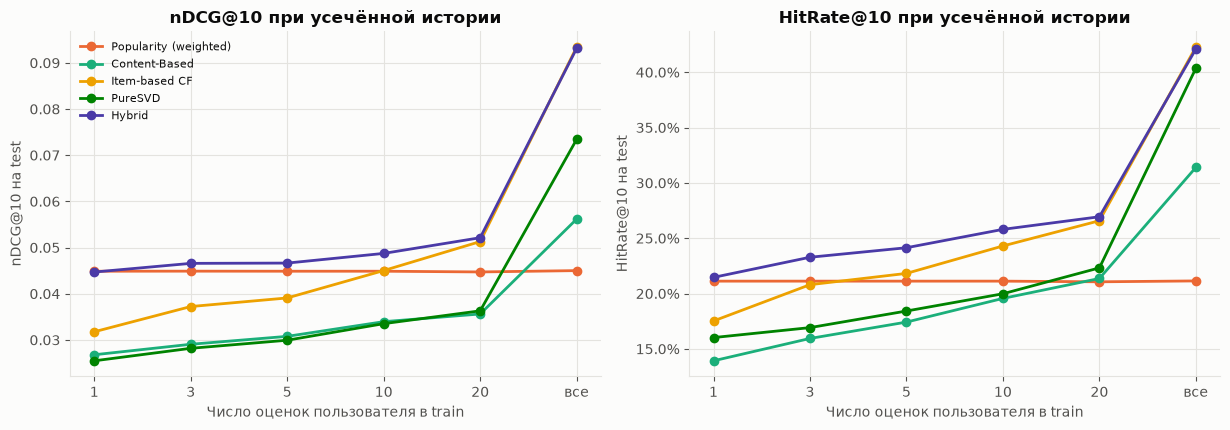

In [61]:
fig = plots.plot_cold_start(cold_table)
plots.save_figure(fig, "cold_start_users")
plt.show()

На 5 000 пользователях test с усечённой историей гибрид при 3–20 оценках лучше Item-based CF и Popularity по nDCG@10 и HitRate@10; при 1 оценке nDCG@10 на уровне Popularity (0.0447 против 0.0449), HitRate@10 — 21.5 % против 21.1 % у Popularity и 17.5 % у Item-based CF. PureSVD при короткой истории уступает Item-based CF: проекция на латентное пространство по 1–5 книгам неустойчива. Coverage@10 гибрида при 1 оценке — 7.8 %: выдача близка к Popularity.

### 6.5. Cold start книг на test

In [62]:
items_train, new_books = cold_start.hide_items(outer.train)
display(book_segments.reindex(new_books).value_counts().to_frame("new_books"))
item_models = cold_start.fit_models(items_train, dataset.books, book_tags)
item_table = cold_start.evaluate_new_item_weights(
    item_models,
    cold_start.with_train(test_set, items_train),
    new_books,
    (0, config.HYBRID_NEW_ITEM_WEIGHT, 1.0),
)
item_table

,new_books
segment,
tail,339
mid,126
head,35


,ndcg,recall,hit_rate,coverage,exposure,recall_new,hit_rate_new,users_with_new
Popularity (weighted),0.0440,0.0261,0.2103,0.0046,0.0000,0.0000,0.0000,26805.0000
Content-Based,0.0555,0.0352,0.3118,0.6681,0.0636,0.0444,0.0605,26805.0000
Item-based CF,0.0941,0.0576,0.4274,0.5279,0.0000,0.0000,0.0000,26805.0000
PureSVD,0.0725,0.0448,0.4026,0.2411,0.0000,0.0000,0.0000,26805.0000
Hybrid (γ=0),0.0934,0.0570,0.4242,0.5142,0.0000,0.0000,0.0000,26805.0000
Hybrid (γ=0.35),0.0926,0.0563,0.4211,0.5461,0.0451,0.0234,0.0320,26805.0000
Hybrid (γ=1),0.0584,0.0340,0.2976,0.4503,0.6433,0.2063,0.2613,26805.0000


Скрытые книги — 339 из long tail, 126 из mid, 35 из head. CF-модели и Popularity их не рекомендуют (Recall@10 по новым книгам — 0). Content-Based находит новые книги (Recall@10 по ним 4.4 %), но уступает Item-based CF по общему nDCG@10 на 41 %. Гибрид с γ = 0.35 отдаёт новым книгам 4.5 % позиций top-10 (Recall@10 по ним 2.3 %) при общем nDCG@10 0.0926 — на 1.6 % ниже Item-based CF и на 0.9 % ниже гибрида без новых книг (γ = 0).